In [1]:
import warnings
warnings.filterwarnings(action='ignore')
from datetime import datetime
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
from AnalysisTools.DBManager import MarketDB
from AnalysisTools.IndexMaker import IndexMaker
from AnalysisTools.Strategy import Strategy

/root/miniconda3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [2]:
# get cushion dataset
etf = "KODEX 레버리지"
start_date = "2015-01-01"
end_date = "2020-12-31"
sample = MarketDB("ETF").get_daily_price(etf, start_date, end_date)

# get indices
maker = IndexMaker(sample)
ma = maker.movingAverage()
ohlc = maker.ohlc()
bollinger = maker.bollinger()
mfi = maker.MFI()
ii = maker.II()
macd = maker.macd()
oscillator = maker.oscillator()

# slice dataframes
start_cut = datetime.strptime("2016-01-01", "%Y-%m-%d").date()
sample = sample[start_cut:]
ma = ma[start_cut:]
ohlc = ohlc[start_cut:]
bollinger = bollinger[start_cut:]
mfi = mfi[start_cut:]
ii = ii[start_cut:]
macd = macd[start_cut:]
oscillator = oscillator[start_cut:]

In [3]:
weights = [1.]
strategy = Strategy(sample, weights)
strategy.MACD(ohlc, ma, macd)
strategy.evaluate()
book = strategy.book

[Long] 2016-01-28 buy 1 occurred: 9110
[Long] 2016-04-01 sell stocks: 9910 gain: 8.78 %
[Long] 2016-11-28 buy 1 occurred: 10535
[Long] 2017-02-02 sell stocks: 12140 gain: 15.23 %
[Long] 2018-03-08 buy 1 occurred: 16390
[Long] 2019-02-28 sell stocks: 13390 gain: -18.3 %
[Long] 2019-06-10 buy 1 occurred: 12125
[Long] 2019-10-30 sell stocks: 12390 gain: 2.19 %
[Long] 2020-04-03 buy 1 occurred: 8380
[Long] 2020-06-25 sell stocks: 11955 gain: 42.66 %

==== Buy And Hold ====
CAGR: 20.53 %
MDD: -66.22 %
VOL: 34.4 %
Sharpe: 71.58 %
==== Evaluate ====
CAGR: 8.58 %
MDD: -36.92 %
VOL: 19.84 %
Sharpe: 51.41 %


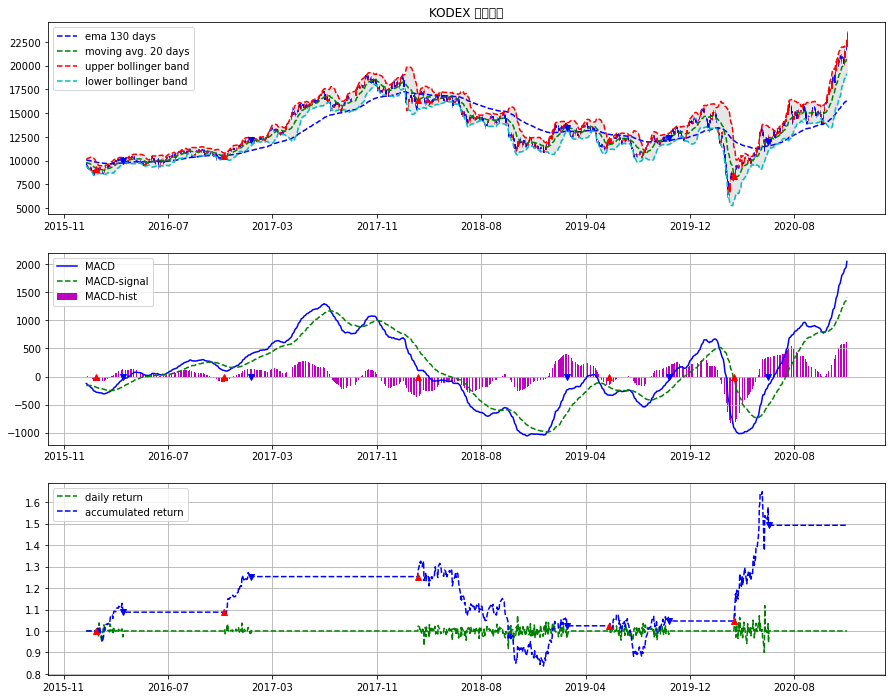

In [4]:
plt.figure(figsize=(15, 12))
p1 = plt.subplot(3, 1, 1)
candlestick_ohlc(p1, ohlc.values, width=.8, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(ma.number, ma.EMA130, 'b--', label='ema 130 days')
plt.plot(bollinger.number, bollinger.center, 'g--', label='moving avg. 20 days')
plt.plot(bollinger.number, bollinger.upper, 'r--', label='upper bollinger band')
plt.plot(bollinger.number, bollinger.lower, 'c--', label='lower bollinger band')
plt.fill_between(bollinger.number, bollinger.upper, bollinger.lower, color='0.9')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(book.number.values[i], book.close.values[i], 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(book.number.values[i], book.close.values[i], 'bv')
    else:
        continue
plt.title(etf)
plt.legend(loc='best')

p2 = plt.subplot(3, 1, 2)
p2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.bar(macd.number, macd.MACDHist, color='m', label='MACD-hist')
plt.plot(macd.number, macd.MACD, color='b', label='MACD')
plt.plot(macd.number, macd.signal, 'g--', label='MACD-signal')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(macd.number.values[i], 0., 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(macd.number.values[i], 0., 'bv')
    else:
        continue
plt.grid(True)
plt.legend(loc='best')

p3 = plt.subplot(3, 1, 3)
p3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(book.number, book.rtn, 'g--', label='daily return')
plt.plot(book.number, book.acc_rtn, 'b--', label='accumulated return')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(book.number.values[i], book.acc_rtn.values[i], 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(book.number.values[i], book.acc_rtn.values[i], 'bv')
    else:
        continue
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [5]:
weights = [0.1, 0.2, 0.3, 0.4]
strategy = Strategy(sample, weights)
strategy.MACD(ohlc, ma, macd)
strategy.evaluate()
book = strategy.book

[Long] 2016-01-28 buy 1 occurred: 9110
[Long] 2016-04-01 sell stocks: 9910 gain: 0.88 %
[Long] 2016-11-28 buy 1 occurred: 10535
[Long] 2017-02-02 sell stocks: 12140 gain: 1.52 %
[Long] 2018-03-08 buy 1 occurred: 16390
[Long] 2018-04-05 buy 2 occurred: 16300
[Long] 2018-04-09 buy 3 occurred: 16335
[Long] 2018-06-04 buy 4 occurred: 16320
[Long] 2019-02-28 sell stocks: 13390 gain: -17.99 %
[Long] 2019-06-10 buy 1 occurred: 12125
[Long] 2019-08-21 buy 2 occurred: 10955
[Long] 2019-08-28 buy 3 occurred: 10705
[Long] 2019-08-30 buy 4 occurred: 10970
[Long] 2019-10-30 sell stocks: 12390 gain: 12.74 %
[Long] 2020-04-03 buy 1 occurred: 8380
[Long] 2020-06-25 sell stocks: 11955 gain: 4.27 %

==== Buy And Hold ====
CAGR: 20.53 %
MDD: -66.22 %
VOL: 34.4 %
Sharpe: 71.58 %
==== Evaluate ====
CAGR: -0.3 %
MDD: -35.04 %
VOL: 12.43 %
Sharpe: 3.8 %


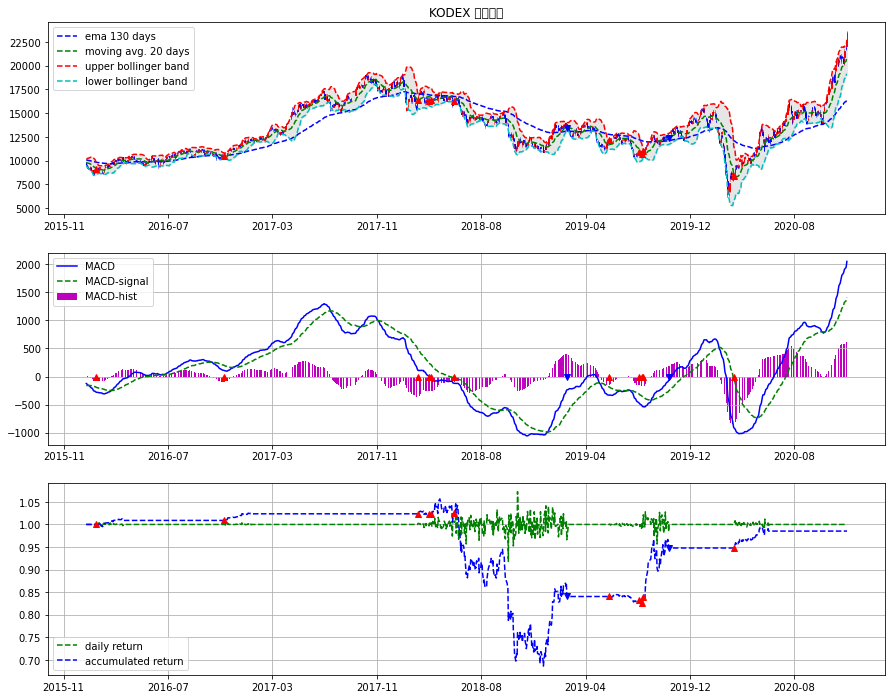

In [6]:
plt.figure(figsize=(15, 12))
p1 = plt.subplot(3, 1, 1)
candlestick_ohlc(p1, ohlc.values, width=.8, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(ma.number, ma.EMA130, 'b--', label='ema 130 days')
plt.plot(bollinger.number, bollinger.center, 'g--', label='moving avg. 20 days')
plt.plot(bollinger.number, bollinger.upper, 'r--', label='upper bollinger band')
plt.plot(bollinger.number, bollinger.lower, 'c--', label='lower bollinger band')
plt.fill_between(bollinger.number, bollinger.upper, bollinger.lower, color='0.9')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(book.number.values[i], book.close.values[i], 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(book.number.values[i], book.close.values[i], 'bv')
    else:
        continue
plt.title(etf)
plt.legend(loc='best')

p2 = plt.subplot(3, 1, 2)
p2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.bar(macd.number, macd.MACDHist, color='m', label='MACD-hist')
plt.plot(macd.number, macd.MACD, color='b', label='MACD')
plt.plot(macd.number, macd.signal, 'g--', label='MACD-signal')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(macd.number.values[i], 0., 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(macd.number.values[i], 0., 'bv')
    else:
        continue
plt.grid(True)
plt.legend(loc='best')

p3 = plt.subplot(3, 1, 3)
p3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(book.number, book.rtn, 'g--', label='daily return')
plt.plot(book.number, book.acc_rtn, 'b--', label='accumulated return')
for i in range(len(book.index)):
    date = book.index[i]
    if book.loc[date, 'trade'] == book.shift(1).loc[date, 'trade'] + 1:
        plt.plot(book.number.values[i], book.acc_rtn.values[i], 'r^')
    elif book.loc[date, 'trade'] == 0 and book.shift(1).loc[date, 'trade'] == len(weights):
        plt.plot(book.number.values[i], book.acc_rtn.values[i], 'bv')
    else:
        continue
plt.grid(True)
plt.legend(loc='best')
plt.show()